In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

In [5]:
import requests
import zipfile
import io

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

response = requests.get(url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("online_retail_data")

print("Dataset downloaded successfully")

Dataset downloaded successfully


In [8]:
import pandas as pd

retail_df = pd.read_excel("online_retail_data/Online Retail.xlsx")
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
retail_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
retail_df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
missing_values = retail_df.isnull().sum()
missing_percent = (missing_values / len(retail_df)) * 100
missing_summary = pd.DataFrame({'MissingCount': missing_values, 'MissingPercent': missing_percent})
missing_summary = missing_summary[missing_summary['MissingCount'] > 0]
missing_summary

,MissingCount,MissingPercent
Description,1454,0.268311
CustomerID,135080,24.926694


In [14]:
cancelled_invoices = retail_df['InvoiceNo'].astype(str).str.startswith('C').sum()
invalid_quantity = (retail_df['Quantity'] <= 0).sum()
invalid_price = (retail_df['UnitPrice'] <= 0).sum()
duplicate_rows = retail_df.duplicated().sum()

data_quality_summary = pd.DataFrame({
    'Issue': ['Missing CustomerID', 'Cancelled Invoices', 'Invalid Quantity (<=0)', 'Invalid UnitPrice (<=0)', 'Duplicate Rows'],
    'Count': [retail_df['CustomerID'].isnull().sum(), cancelled_invoices, invalid_quantity, invalid_price, duplicate_rows]
})
data_quality_summary

,Issue,Count
0,Missing CustomerID,135080
1,Cancelled Invoices,9288
2,Invalid Quantity (<=0),10624
3,Invalid UnitPrice (<=0),2517
4,Duplicate Rows,5268


In [15]:
clean_df = retail_df.copy()
clean_df = clean_df.dropna(subset=['CustomerID'])
clean_df = clean_df[~clean_df['InvoiceNo'].astype(str).str.startswith('C')]
clean_df = clean_df[(clean_df['Quantity'] > 0) & (clean_df['UnitPrice'] > 0)]
clean_df = clean_df.drop_duplicates()
clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'])
clean_df['CustomerID'] = clean_df['CustomerID'].astype(int)
clean_df['TotalPrice'] = clean_df['Quantity'] * clean_df['UnitPrice']
clean_df.shape

(392692, 9)

In [16]:
rows_removed = len(retail_df) - len(clean_df)
rows_removed_percent = (rows_removed / len(retail_df)) * 100
print(f'Rows removed during cleaning: {rows_removed} ({rows_removed_percent:.2f}% of original data)')
print(f'Remaining transactions: {len(clean_df)}')
print(f'Remaining unique customers: {clean_df["CustomerID"].nunique()}')

Rows removed during cleaning: 149217 (27.54% of original data)
Remaining transactions: 392692
Remaining unique customers: 4338


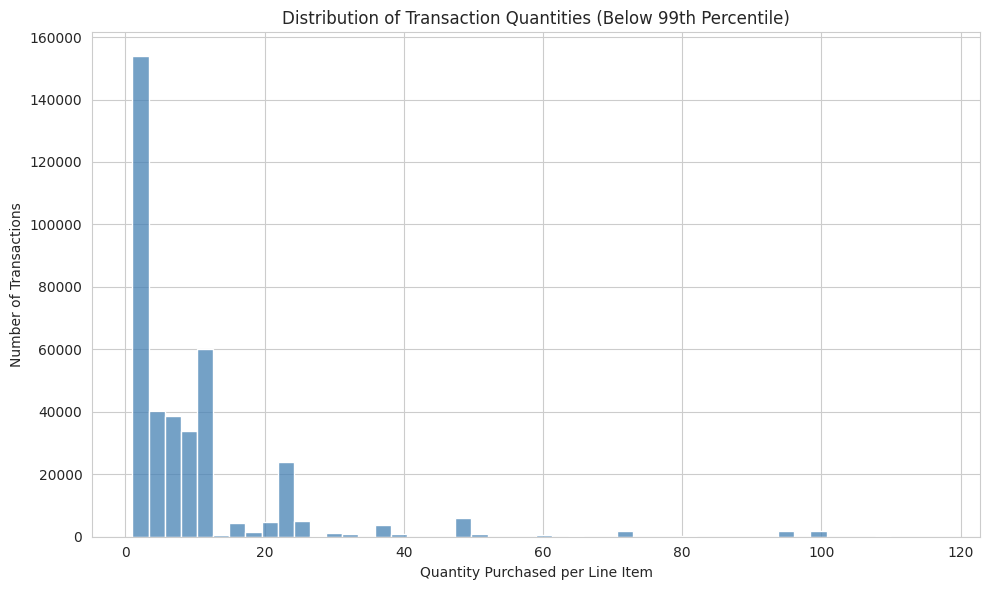

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(clean_df[clean_df['Quantity'] < clean_df['Quantity'].quantile(0.99)]['Quantity'], bins=50, color='steelblue')
plt.title('Distribution of Transaction Quantities (Below 99th Percentile)')
plt.xlabel('Quantity Purchased per Line Item')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

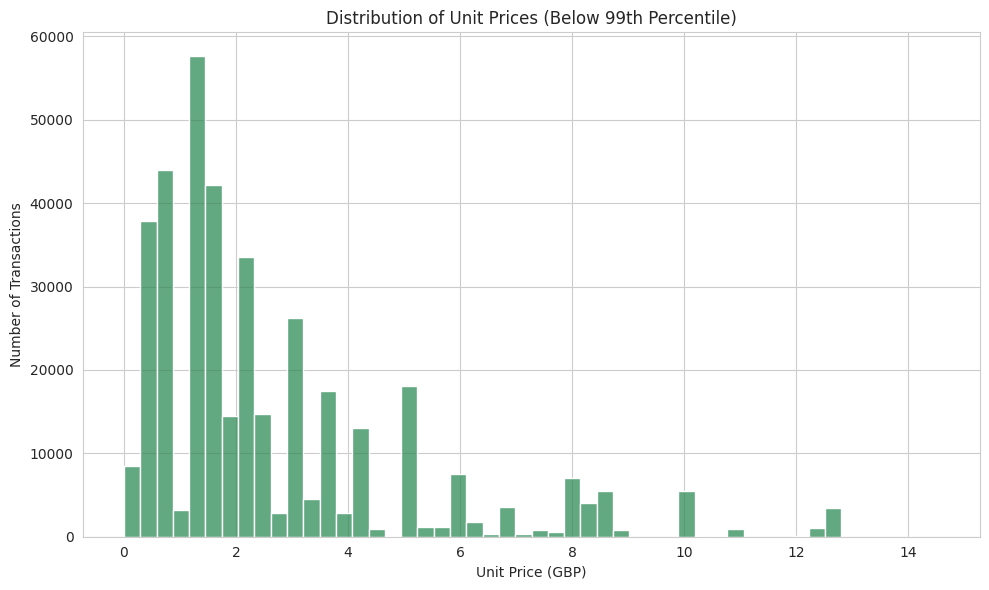

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(clean_df[clean_df['UnitPrice'] < clean_df['UnitPrice'].quantile(0.99)]['UnitPrice'], bins=50, color='seagreen')
plt.title('Distribution of Unit Prices (Below 99th Percentile)')
plt.xlabel('Unit Price (GBP)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

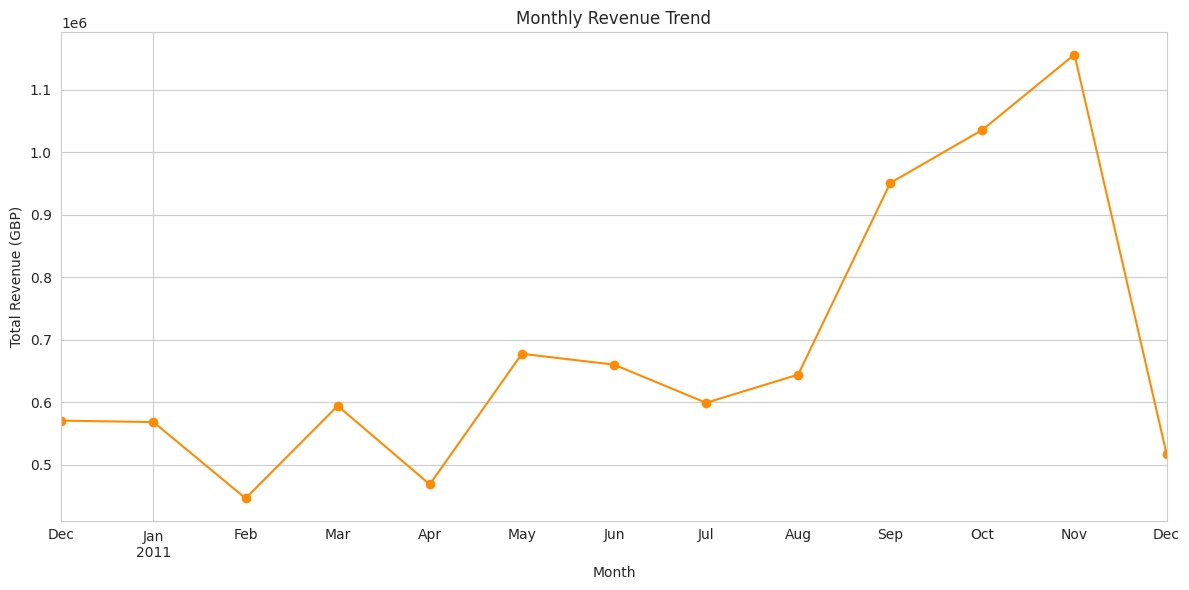

In [19]:
monthly_sales = clean_df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()

plt.figure(figsize=(12, 6))
monthly_sales.plot(marker='o', color='darkorange')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (GBP)')
plt.tight_layout()
plt.show()

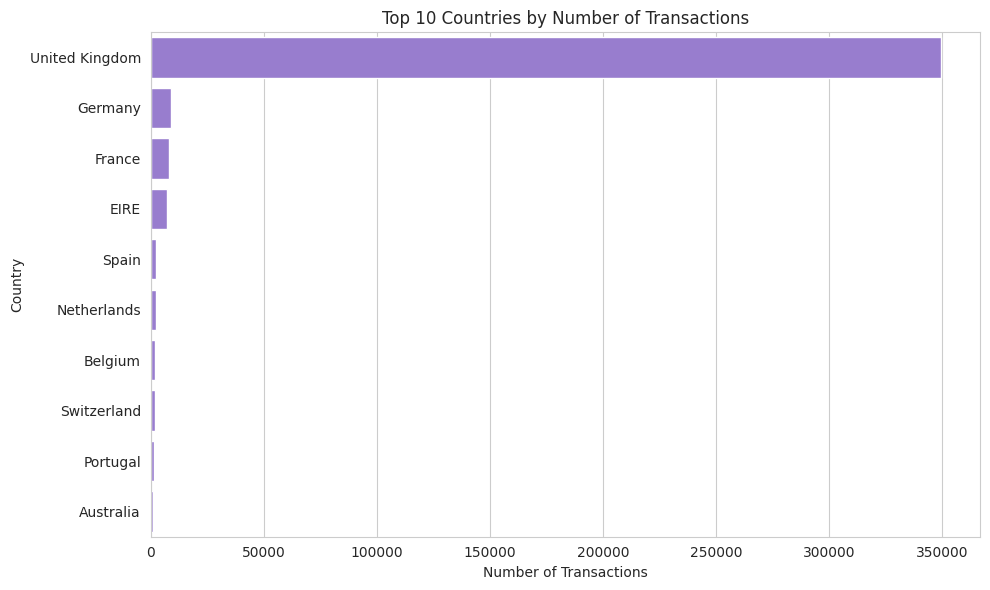

In [20]:
top_countries = clean_df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, color='mediumpurple')
plt.title('Top 10 Countries by Number of Transactions')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [21]:
reference_date = clean_df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Reference date used for Recency calculation: {reference_date.date()}')

Reference date used for Recency calculation: 2011-12-10


In [22]:
rfm_df = clean_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm_df.shape

(4338, 4)

In [23]:
rfm_df.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


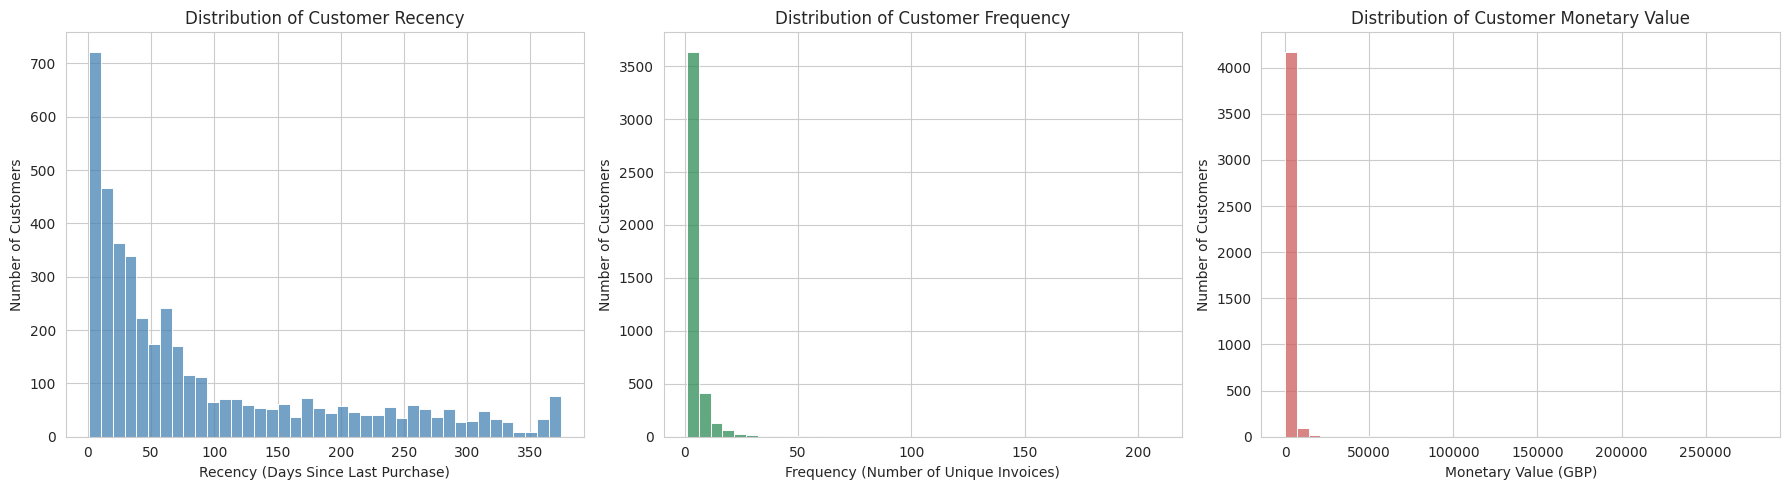

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_df['Recency'], bins=40, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Customer Recency')
axes[0].set_xlabel('Recency (Days Since Last Purchase)')
axes[0].set_ylabel('Number of Customers')

sns.histplot(rfm_df['Frequency'], bins=40, color='seagreen', ax=axes[1])
axes[1].set_title('Distribution of Customer Frequency')
axes[1].set_xlabel('Frequency (Number of Unique Invoices)')
axes[1].set_ylabel('Number of Customers')

sns.histplot(rfm_df['Monetary'], bins=40, color='indianred', ax=axes[2])
axes[2].set_title('Distribution of Customer Monetary Value')
axes[2].set_xlabel('Monetary Value (GBP)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

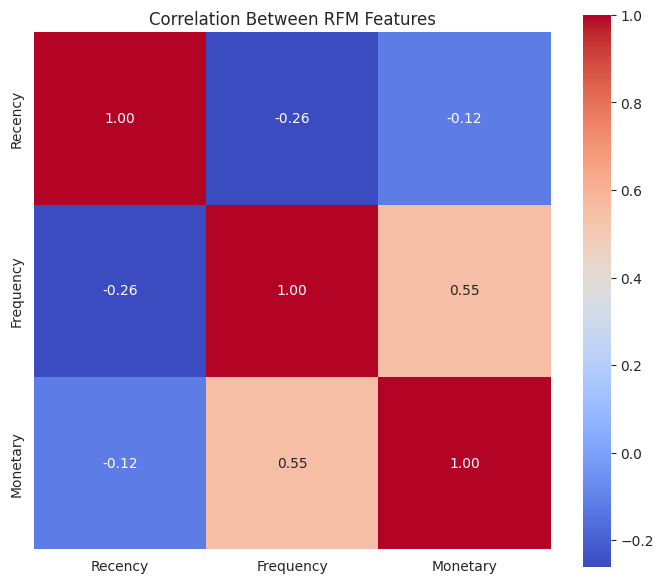

In [25]:
plt.figure(figsize=(7, 6))
rfm_corr = rfm_df[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(rfm_corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Between RFM Features')
plt.tight_layout()
plt.show()

In [26]:
rfm_features = rfm_df.copy()
rfm_features['Frequency_log'] = np.log1p(rfm_features['Frequency'])
rfm_features['Monetary_log'] = np.log1p(rfm_features['Monetary'])

model_features = ['Recency', 'Frequency_log', 'Monetary_log']
rfm_features[model_features].describe()

,Recency,Frequency_log,Monetary_log
count,4338.000000,4338.000000,4338.000000
mean,92.536422,1.345582,6.588562
std,100.014169,0.683104,1.258438
min,1.000000,0.693147,1.558145
25%,18.000000,0.693147,5.728418
50%,51.000000,1.098612,6.506636
75%,142.000000,1.791759,7.415535
max,374.000000,5.347108,12.543284


In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), model_features)
    ]
)

preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

rfm_scaled = preprocessing_pipeline.fit_transform(rfm_features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=model_features)
rfm_scaled_df.describe()

,Recency,Frequency_log,Monetary_log
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,-7.206980e-17,-3.669008e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-9.552143e-01,-3.997811e+00
25%,-7.453445e-01,-9.552143e-01,-6.835802e-01
50%,-4.153533e-01,-3.615828e-01,-6.510929e-02
75%,4.946227e-01,6.532370e-01,6.572178e-01
max,2.814561e+00,5.858535e+00,4.732381e+00


In [28]:
k_range = range(2, 11)
inertia_values = []
silhouette_values = []

for k in k_range:
    kmeans_model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    kmeans_labels = kmeans_model.fit_predict(rfm_scaled)
    inertia_values.append(kmeans_model.inertia_)
    silhouette_values.append(silhouette_score(rfm_scaled, kmeans_labels))

kmeans_selection_df = pd.DataFrame({'K': list(k_range), 'Inertia': inertia_values, 'SilhouetteScore': silhouette_values})
kmeans_selection_df

,K,Inertia,SilhouetteScore
0,2,6874.932051,0.406237
1,3,4299.066899,0.415697
2,4,3243.032792,0.379542
3,5,2760.794356,0.343481
4,6,2396.854906,0.329923
5,7,2166.958608,0.300766
6,8,1961.088789,0.299870
7,9,1819.158195,0.282816
8,10,1687.778543,0.281866


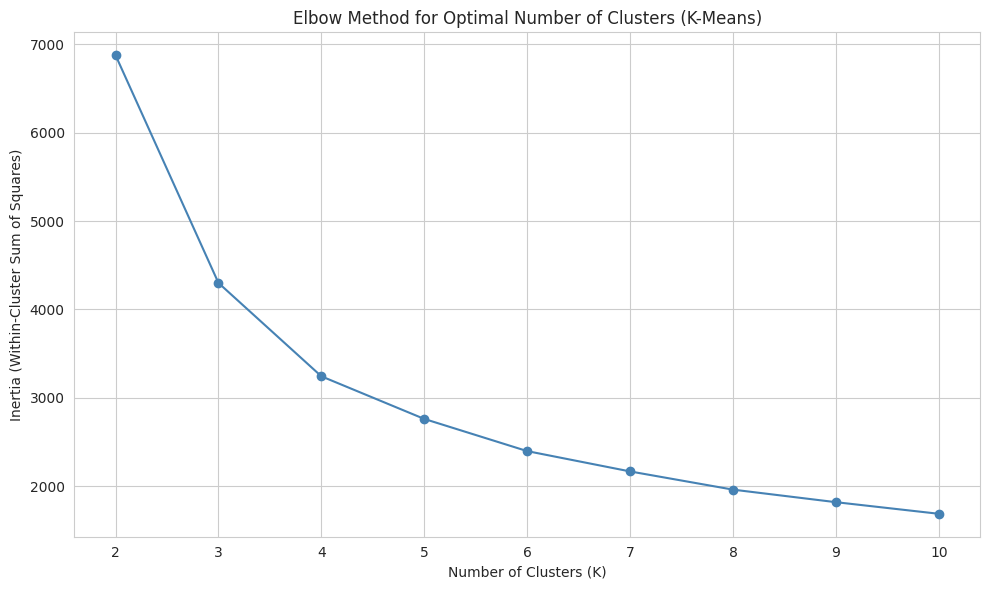

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(kmeans_selection_df['K'], kmeans_selection_df['Inertia'], marker='o', color='steelblue')
plt.title('Elbow Method for Optimal Number of Clusters (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

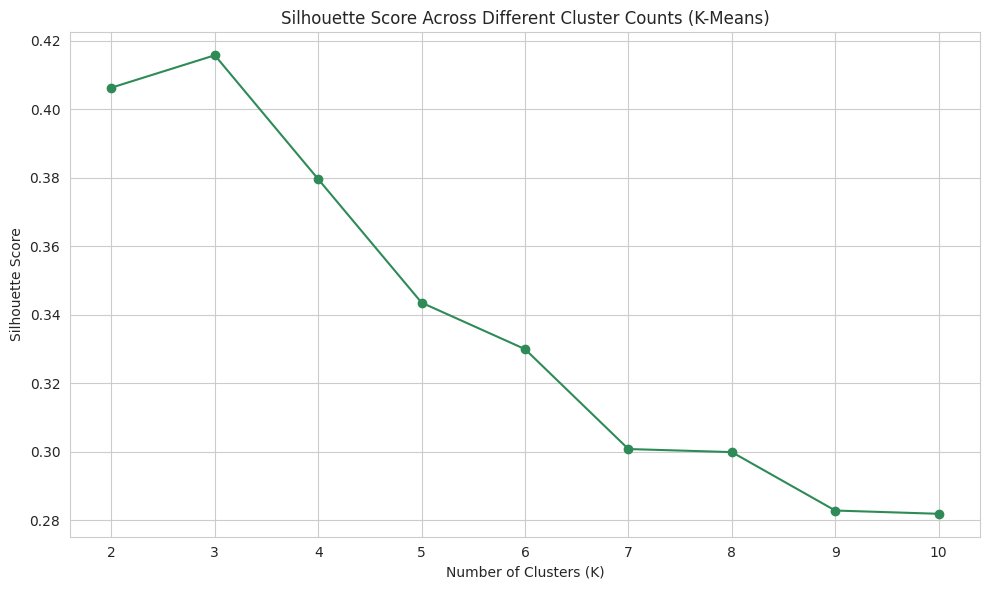

In [30]:
plt.figure(figsize=(10, 6))
plt.plot(kmeans_selection_df['K'], kmeans_selection_df['SilhouetteScore'], marker='o', color='seagreen')
plt.title('Silhouette Score Across Different Cluster Counts (K-Means)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

In [31]:
optimal_k = int(kmeans_selection_df.loc[kmeans_selection_df['SilhouetteScore'].idxmax(), 'K'])
print(f'Number of clusters selected for K-Means (highest silhouette score): K = {optimal_k}')

Number of clusters selected for K-Means (highest silhouette score): K = 3


In [32]:
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
kmeans_cluster_labels = final_kmeans.fit_predict(rfm_scaled)
rfm_features['KMeans_Cluster'] = kmeans_cluster_labels

kmeans_silhouette = silhouette_score(rfm_scaled, kmeans_cluster_labels)
kmeans_db_score = davies_bouldin_score(rfm_scaled, kmeans_cluster_labels)
kmeans_ch_score = calinski_harabasz_score(rfm_scaled, kmeans_cluster_labels)

print(f'K-Means Silhouette Score: {kmeans_silhouette:.4f}')
print(f'K-Means Davies-Bouldin Index: {kmeans_db_score:.4f}')
print(f'K-Means Calinski-Harabasz Score: {kmeans_ch_score:.2f}')

K-Means Silhouette Score: 0.4157
K-Means Davies-Bouldin Index: 0.8250
K-Means Calinski-Harabasz Score: 4393.91


In [33]:
dendrogram_sample_size = min(200, rfm_scaled.shape[0])
rng = np.random.RandomState(RANDOM_STATE)
sample_indices = rng.choice(rfm_scaled.shape[0], size=dendrogram_sample_size, replace=False)
rfm_scaled_sample = rfm_scaled[sample_indices]
linkage_matrix = linkage(rfm_scaled_sample, method='ward')

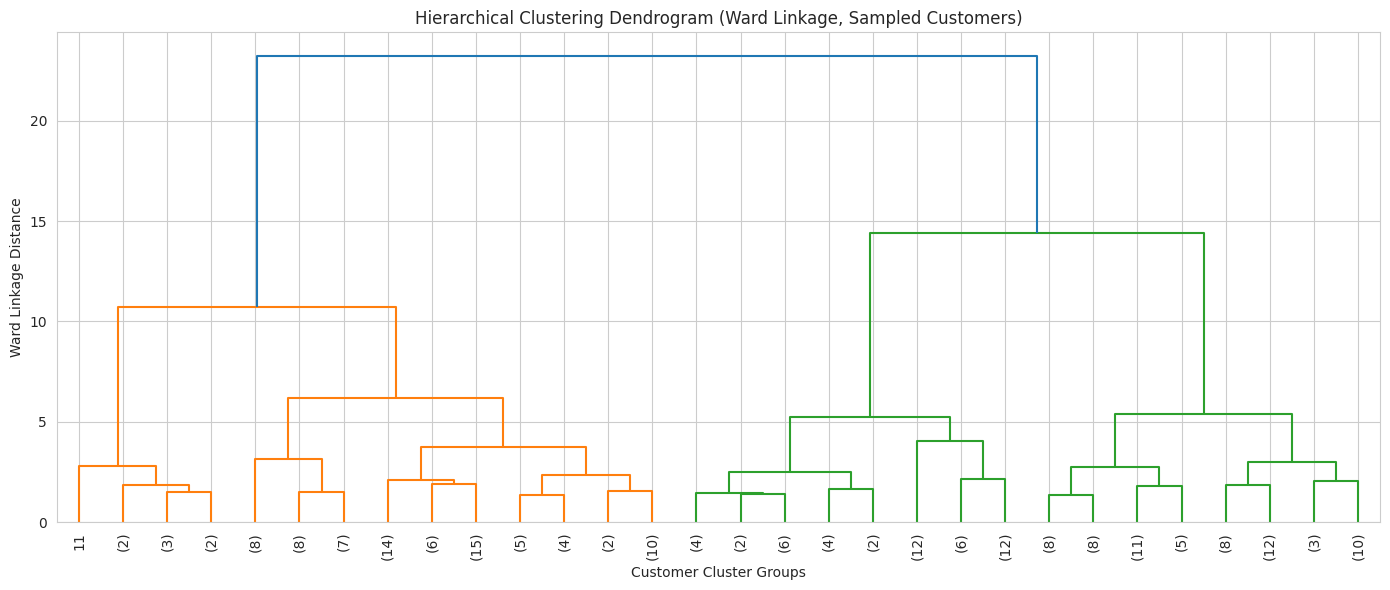

In [34]:
plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, Sampled Customers)')
plt.xlabel('Customer Cluster Groups')
plt.ylabel('Ward Linkage Distance')
plt.tight_layout()
plt.show()

In [35]:
hier_k_range = range(2, 8)
hier_silhouette_values = []

for k in hier_k_range:
    hier_model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    hier_labels_k = hier_model.fit_predict(rfm_scaled)
    hier_silhouette_values.append(silhouette_score(rfm_scaled, hier_labels_k))

hier_selection_df = pd.DataFrame({'K': list(hier_k_range), 'SilhouetteScore': hier_silhouette_values})
hier_selection_df

,K,SilhouetteScore
0,2,0.397486
1,3,0.401313
2,4,0.343750
3,5,0.296964
4,6,0.271774
5,7,0.262060


In [36]:
optimal_hier_k = int(hier_selection_df.loc[hier_selection_df['SilhouetteScore'].idxmax(), 'K'])
print(f'Number of clusters selected for Hierarchical Clustering (highest silhouette score): K = {optimal_hier_k}')

final_hierarchical = AgglomerativeClustering(n_clusters=optimal_hier_k, linkage='ward')
hierarchical_cluster_labels = final_hierarchical.fit_predict(rfm_scaled)
rfm_features['Hierarchical_Cluster'] = hierarchical_cluster_labels

hierarchical_silhouette = silhouette_score(rfm_scaled, hierarchical_cluster_labels)
hierarchical_db_score = davies_bouldin_score(rfm_scaled, hierarchical_cluster_labels)
hierarchical_ch_score = calinski_harabasz_score(rfm_scaled, hierarchical_cluster_labels)

print(f'Hierarchical Clustering Silhouette Score: {hierarchical_silhouette:.4f}')
print(f'Hierarchical Clustering Davies-Bouldin Index: {hierarchical_db_score:.4f}')
print(f'Hierarchical Clustering Calinski-Harabasz Score: {hierarchical_ch_score:.2f}')

Number of clusters selected for Hierarchical Clustering (highest silhouette score): K = 3
Hierarchical Clustering Silhouette Score: 0.4013
Hierarchical Clustering Davies-Bouldin Index: 0.8548
Hierarchical Clustering Calinski-Harabasz Score: 4227.25


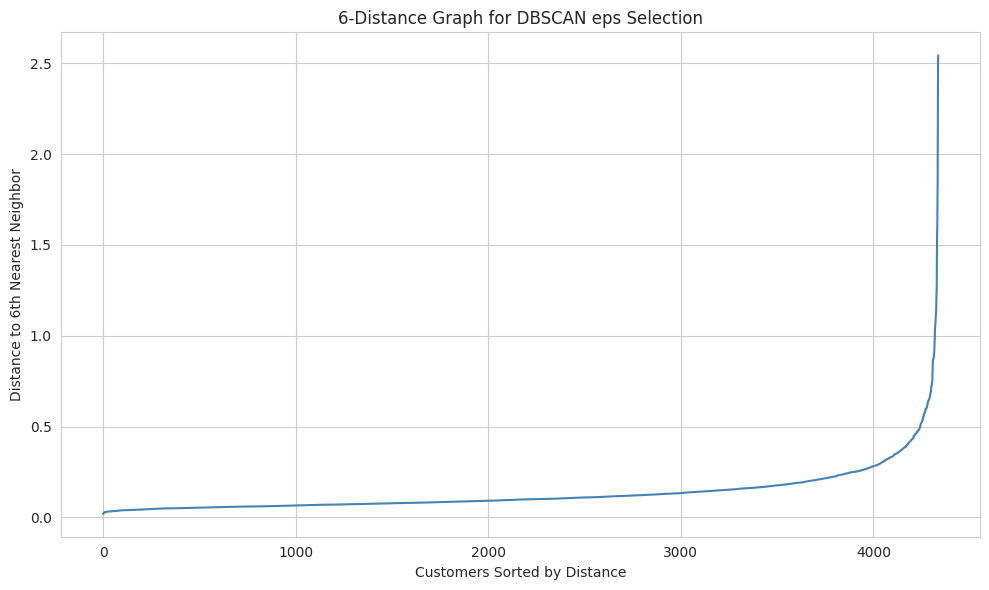

In [37]:
min_samples_value = 2 * rfm_scaled.shape[1]

nearest_neighbors = NearestNeighbors(n_neighbors=min_samples_value)
neighbors_fit = nearest_neighbors.fit(rfm_scaled)
distances, indices = neighbors_fit.kneighbors(rfm_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances, color='steelblue')
plt.title(f'{min_samples_value}-Distance Graph for DBSCAN eps Selection')
plt.xlabel('Customers Sorted by Distance')
plt.ylabel(f'Distance to {min_samples_value}th Nearest Neighbor')
plt.tight_layout()
plt.show()

In [38]:
point_indices = np.arange(len(k_distances))
line_start = np.array([point_indices[0], k_distances[0]])
line_end = np.array([point_indices[-1], k_distances[-1]])
line_vector = line_end - line_start
line_vector_norm = line_vector / np.linalg.norm(line_vector)

points = np.column_stack([point_indices, k_distances])
vectors_from_start = points - line_start
projection_length = vectors_from_start @ line_vector_norm
projection_points = np.outer(projection_length, line_vector_norm) + line_start
perpendicular_distance = np.linalg.norm(points - projection_points, axis=1)

knee_index = int(np.argmax(perpendicular_distance))
selected_eps = round(float(k_distances[knee_index]), 3)
print(f'min_samples selected: {min_samples_value}')
print(f'eps selected using k-distance knee point: {selected_eps}')

min_samples selected: 6
eps selected using k-distance knee point: 0.291


In [39]:
dbscan_model = DBSCAN(eps=selected_eps, min_samples=min_samples_value)
dbscan_cluster_labels = dbscan_model.fit_predict(rfm_scaled)
rfm_features['DBSCAN_Cluster'] = dbscan_cluster_labels

num_dbscan_clusters = len(set(dbscan_cluster_labels)) - (1 if -1 in dbscan_cluster_labels else 0)
num_noise_points = int((dbscan_cluster_labels == -1).sum())

print(f'Number of clusters found by DBSCAN: {num_dbscan_clusters}')
print(f'Number of noise points identified: {num_noise_points} ({num_noise_points / len(dbscan_cluster_labels) * 100:.2f}% of customers)')

if num_dbscan_clusters > 1:
    non_noise_mask = dbscan_cluster_labels != -1
    dbscan_silhouette = silhouette_score(rfm_scaled[non_noise_mask], dbscan_cluster_labels[non_noise_mask])
    dbscan_db_score = davies_bouldin_score(rfm_scaled[non_noise_mask], dbscan_cluster_labels[non_noise_mask])
    dbscan_ch_score = calinski_harabasz_score(rfm_scaled[non_noise_mask], dbscan_cluster_labels[non_noise_mask])
else:
    dbscan_silhouette = np.nan
    dbscan_db_score = np.nan
    dbscan_ch_score = np.nan

print(f'DBSCAN Silhouette Score (excluding noise): {dbscan_silhouette}')

Number of clusters found by DBSCAN: 6
Number of noise points identified: 186 (4.29% of customers)
DBSCAN Silhouette Score (excluding noise): 0.008971217994949498


In [40]:
pca_model = PCA(n_components=2, random_state=RANDOM_STATE)
rfm_pca = pca_model.fit_transform(rfm_scaled)
rfm_features['PCA1'] = rfm_pca[:, 0]
rfm_features['PCA2'] = rfm_pca[:, 1]

explained_variance = pca_model.explained_variance_ratio_.sum()
print(f'Total variance explained by 2 principal components: {explained_variance * 100:.2f}%')

Total variance explained by 2 principal components: 93.65%


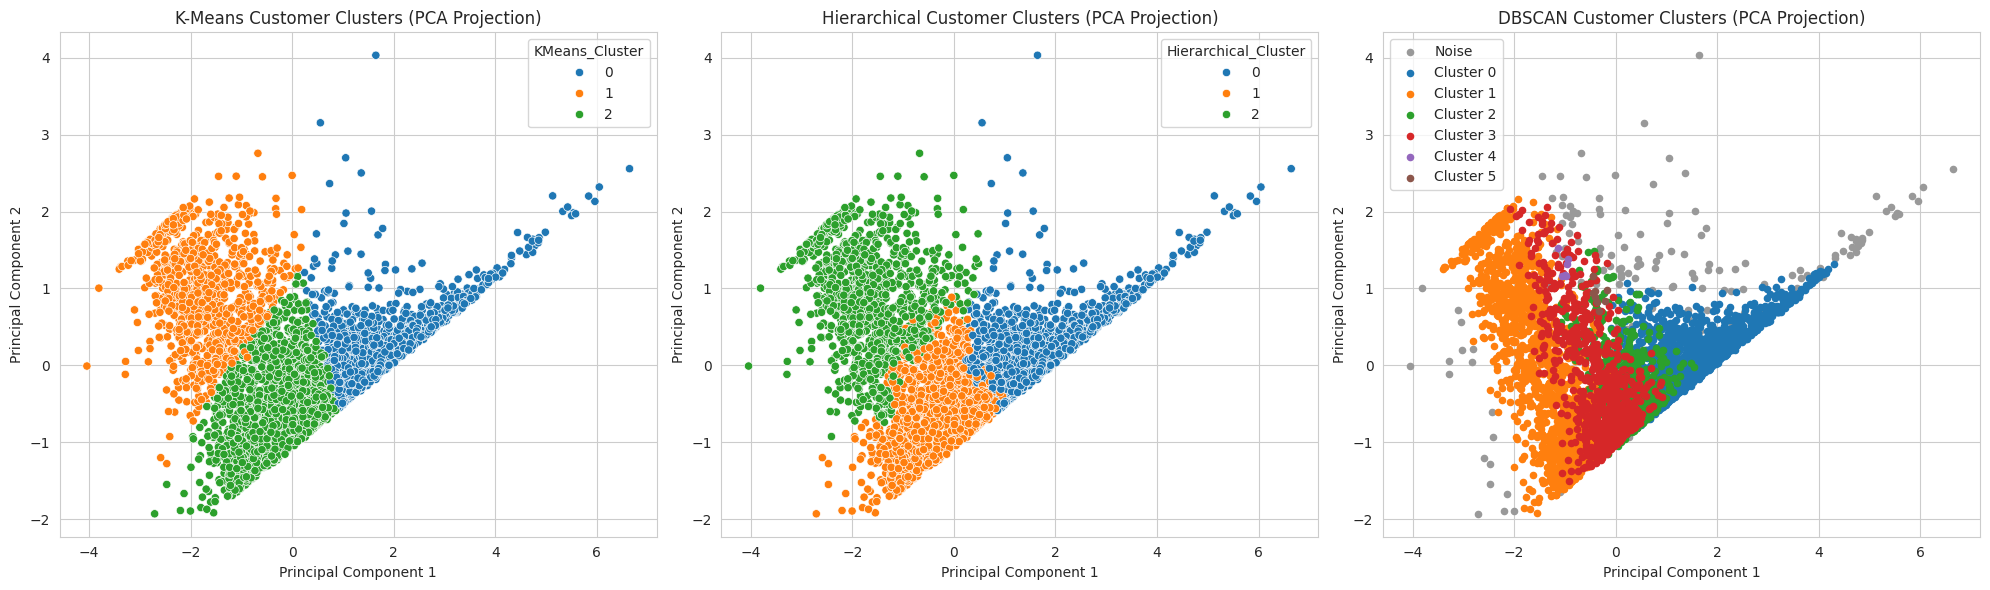

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='tab10', data=rfm_features, ax=axes[0], legend='full')
axes[0].set_title('K-Means Customer Clusters (PCA Projection)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

sns.scatterplot(x='PCA1', y='PCA2', hue='Hierarchical_Cluster', palette='tab10', data=rfm_features, ax=axes[1], legend='full')
axes[1].set_title('Hierarchical Customer Clusters (PCA Projection)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

dbscan_palette = sns.color_palette('tab10', num_dbscan_clusters)
dbscan_colors = {label: (dbscan_palette[label] if label != -1 else (0.6, 0.6, 0.6)) for label in set(dbscan_cluster_labels)}
for label in sorted(set(dbscan_cluster_labels)):
    subset = rfm_features[rfm_features['DBSCAN_Cluster'] == label]
    axes[2].scatter(subset['PCA1'], subset['PCA2'], color=dbscan_colors[label], label=('Noise' if label == -1 else f'Cluster {label}'), s=20)
axes[2].set_title('DBSCAN Customer Clusters (PCA Projection)')
axes[2].set_xlabel('Principal Component 1')
axes[2].set_ylabel('Principal Component 2')
axes[2].legend()

plt.tight_layout()
plt.show()

In [42]:
comparison_records = [
    {'Algorithm': 'K-Means', 'Number of Clusters': optimal_k, 'Noise Points': '-', 'Silhouette Score': round(kmeans_silhouette, 4), 'Davies-Bouldin': round(kmeans_db_score, 4), 'Calinski-Harabasz': round(kmeans_ch_score, 2)},
    {'Algorithm': 'Hierarchical', 'Number of Clusters': optimal_hier_k, 'Noise Points': '-', 'Silhouette Score': round(hierarchical_silhouette, 4), 'Davies-Bouldin': round(hierarchical_db_score, 4), 'Calinski-Harabasz': round(hierarchical_ch_score, 2)},
    {'Algorithm': 'DBSCAN', 'Number of Clusters': num_dbscan_clusters, 'Noise Points': num_noise_points, 'Silhouette Score': round(dbscan_silhouette, 4) if not np.isnan(dbscan_silhouette) else 'N/A', 'Davies-Bouldin': round(dbscan_db_score, 4) if not np.isnan(dbscan_db_score) else 'N/A', 'Calinski-Harabasz': round(dbscan_ch_score, 2) if not np.isnan(dbscan_ch_score) else 'N/A'}
]

algorithm_comparison_df = pd.DataFrame(comparison_records)
algorithm_comparison_df

,Algorithm,Number of Clusters,Noise Points,Silhouette Score,Davies-Bouldin,Calinski-Harabasz
0,K-Means,3,-,0.4157,0.8250,4393.91
1,Hierarchical,3,-,0.4013,0.8548,4227.25
2,DBSCAN,6,186,0.0090,1.6336,1095.59


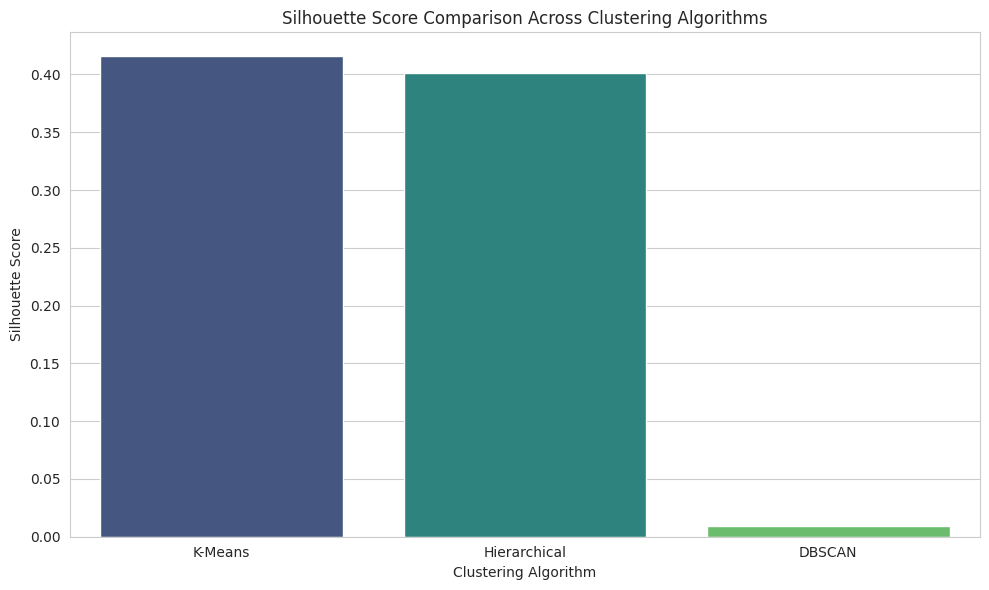

In [43]:
plt.figure(figsize=(10, 6))
numeric_comparison = algorithm_comparison_df.copy()
numeric_comparison['Silhouette Score'] = pd.to_numeric(numeric_comparison['Silhouette Score'], errors='coerce')
sns.barplot(x='Algorithm', y='Silhouette Score', data=numeric_comparison, palette='viridis')
plt.title('Silhouette Score Comparison Across Clustering Algorithms')
plt.xlabel('Clustering Algorithm')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

In [44]:
valid_scores = numeric_comparison.dropna(subset=['Silhouette Score'])
best_algorithm = valid_scores.loc[valid_scores['Silhouette Score'].idxmax(), 'Algorithm']
print(f'Algorithm with the highest silhouette score: {best_algorithm}')

Algorithm with the highest silhouette score: K-Means


In [45]:
cluster_column_map = {'K-Means': 'KMeans_Cluster', 'Hierarchical': 'Hierarchical_Cluster', 'DBSCAN': 'DBSCAN_Cluster'}
final_cluster_column = cluster_column_map[best_algorithm]

profiling_df = rfm_features[rfm_features[final_cluster_column] != -1].copy() if best_algorithm == 'DBSCAN' else rfm_features.copy()

cluster_profile = profiling_df.groupby(final_cluster_column).agg(
    Customers=('CustomerID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2).reset_index().rename(columns={final_cluster_column: 'Cluster'})

cluster_profile

,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
0,0,1320,30.10,9.84,5492.04
1,1,981,255.11,1.39,397.17
2,2,2037,54.70,2.05,612.71


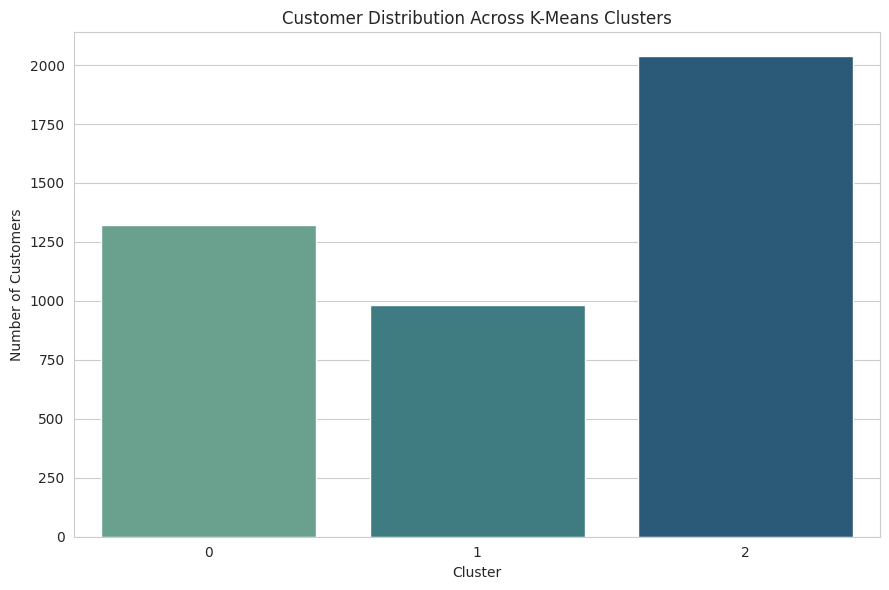

In [46]:
plt.figure(figsize=(9, 6))
sns.barplot(x='Cluster', y='Customers', data=cluster_profile, palette='crest')
plt.title(f'Customer Distribution Across {best_algorithm} Clusters')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

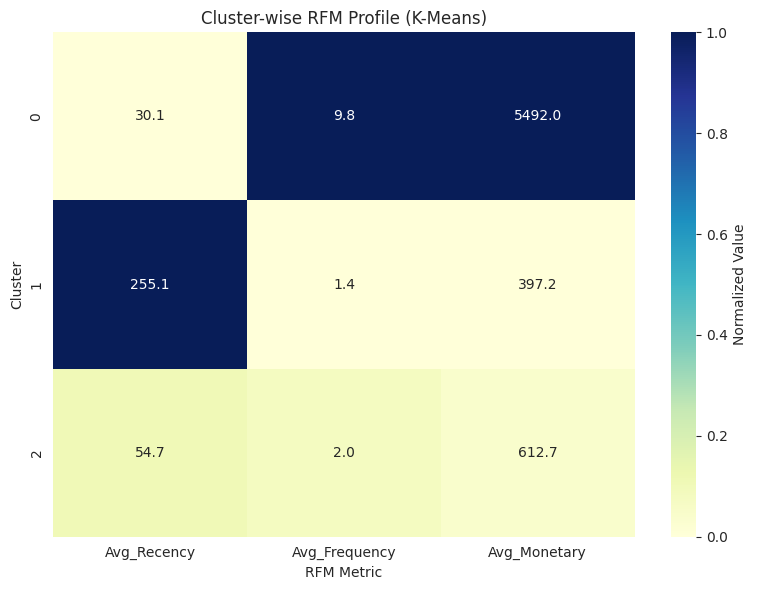

In [47]:
profile_heatmap_data = cluster_profile.set_index('Cluster')[['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary']]
profile_heatmap_scaled = (profile_heatmap_data - profile_heatmap_data.min()) / (profile_heatmap_data.max() - profile_heatmap_data.min())

plt.figure(figsize=(8, 6))
sns.heatmap(profile_heatmap_scaled, annot=profile_heatmap_data, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Normalized Value'})
plt.title(f'Cluster-wise RFM Profile ({best_algorithm})')
plt.xlabel('RFM Metric')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

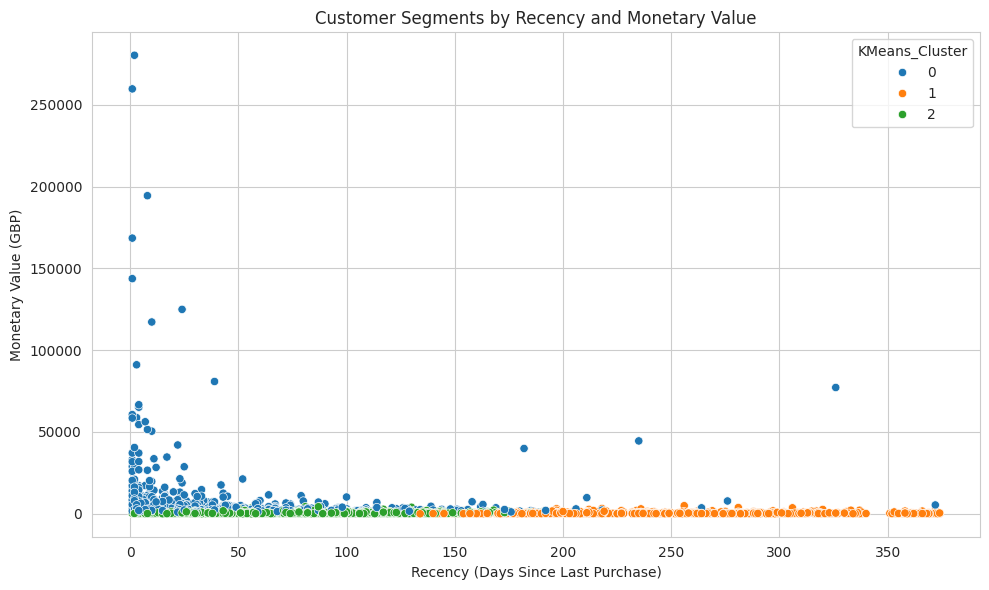

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Recency', y='Monetary', hue=final_cluster_column, palette='tab10', data=profiling_df, legend='full')
plt.title('Customer Segments by Recency and Monetary Value')
plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Monetary Value (GBP)')
plt.tight_layout()
plt.show()

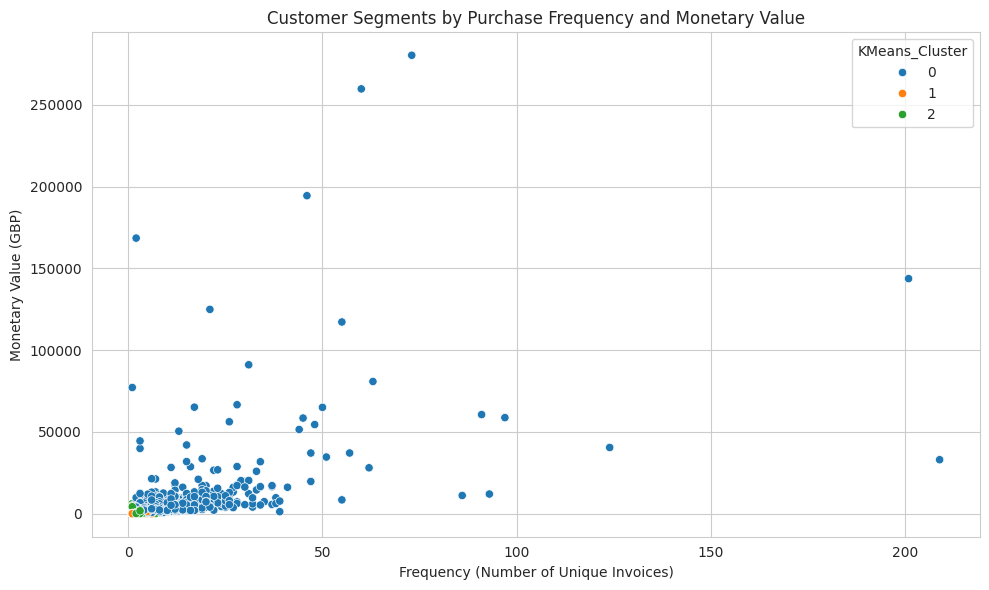

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Frequency', y='Monetary', hue=final_cluster_column, palette='tab10', data=profiling_df, legend='full')
plt.title('Customer Segments by Purchase Frequency and Monetary Value')
plt.xlabel('Frequency (Number of Unique Invoices)')
plt.ylabel('Monetary Value (GBP)')
plt.tight_layout()
plt.show()

In [50]:
overall_avg_recency = cluster_profile['Avg_Recency'].mean()
overall_avg_frequency = cluster_profile['Avg_Frequency'].mean()
overall_avg_monetary = cluster_profile['Avg_Monetary'].mean()

def interpret_cluster(row):
    high_monetary = row['Avg_Monetary'] >= overall_avg_monetary
    high_frequency = row['Avg_Frequency'] >= overall_avg_frequency
    high_recency = row['Avg_Recency'] >= overall_avg_recency

    if high_monetary and high_frequency and not high_recency:
        return 'High-Value, Frequent, Recently Active Customers'
    if high_monetary and not high_frequency and not high_recency:
        return 'High-Value, Recently Active Customers'
    if not high_monetary and high_frequency and not high_recency:
        return 'Frequent but Lower-Spending Customers'
    if high_recency and not high_monetary and not high_frequency:
        return 'Inactive, Low-Value Customers'
    if high_recency and high_monetary:
        return 'High-Value Customers at Risk of Churning'
    if not high_recency and not high_monetary and not high_frequency:
        return 'Occasional, Low-Engagement Customers'
    return 'Moderate-Engagement Customers'

cluster_profile['Interpretation'] = cluster_profile.apply(interpret_cluster, axis=1)
cluster_profile

,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Interpretation
0,0,1320,30.10,9.84,5492.04,"High-Value, Frequent, Recently Active Customers"
1,1,981,255.11,1.39,397.17,"Inactive, Low-Value Customers"
2,2,2037,54.70,2.05,612.71,"Occasional, Low-Engagement Customers"
